## Procesamiento y sistematización de extractos bancario

Esta notebook surge de la necesidad de transformar información bancaria histórica, almacenada en múltiples extractos mensuales en formato PDF, en datos estructurados y analizables.

El proceso consiste en:

- Extraer los movimientos diarios de cada extracto bancario.
- Transformar y limpiar la información obtenida.
- Consolidar todos los períodos en un único DataFrame.

La información final incluye la fecha, número de comprobante, concepto, Debitos, Creditos y saldo de la cuenta corriente, y queda disponible para su posterior análisis y actualización.


#### Estructura del pdf correspondiente a los extractos bancarios

<div align="center">
    <img src="../img/img_resumen.png" width="650">
</div>

![Resumen de cuenta](D:/Josefina/Proyectos/Datascience/Data_Analytics/Contabilidad_Empresa/img/img_resumen.png)

In [1]:
import pdfplumber
import pandas as pd
import re # Permite trabajar con expresiones regulares
import matplotlib.pyplot as plt
import os

print("Librerias ok")

Librerias ok


### Contruccion de funcion completa

In [2]:
def extraer_movimientos_bancarios(ruta_pdf):
    registros = []
    leyendo_movimientos = False
    fin_movimientos = False
    fecha_actual = None
    ultimo_registro = None
    saldo_total = None
    saldo_inicial = None

    columnas = ["Fecha", "Comprobante", "Movimiento", "Debito", "Credito", "Saldo en cuenta"]
    patron_monto = re.compile(r"-?\$?\s?\d{1,3}(?:\.\d{3})*,\d{2}")
    def convertir_monto(texto):
        if texto is None:
            return "NA"
        texto = texto.strip()
        negativo = "-" in texto
        texto = texto.replace("$", "").replace("-", "").replace(" ", "").replace(".", "").replace(",", ".")
        try:
            valor = float(texto)
        except ValueError:
            return "NA"
        if negativo:
            valor *= -1
        return valor
    
    def fecha_al_inicio(texto):
        resultado = re.match(r"^\s*(\d{2}/\d{2}/\d{2})", texto)
        if resultado:
            return resultado.group(1)
        return None

    def agrupar_palabras_en_lineas(palabras, tolerancia_vertical=3):
        palabras = sorted(palabras, key=lambda palabra: palabra["top"])
        lineas = []
        for palabra in palabras:
            agregada = False
            for linea in lineas:
                top_linea = linea[0]["top"]
                if abs(palabra["top"] - top_linea) <= tolerancia_vertical:
                    linea.append(palabra)
                    agregada = True
                    break

            if not agregada:
                lineas.append([palabra])
        for linea in lineas:
            linea.sort(key=lambda palabra: palabra["x0"])
        return lineas

    def es_fecha_sola(texto):
        return bool(re.fullmatch(r"\d{2}/\d{2}/\d{2}", texto.strip()))
    def es_numero_de_pagina(texto):
        return bool(re.fullmatch(r"\d+\s*-\s*\d+", texto.strip()))

    def es_informacion_a_ignorar(texto): # Ojo con esta parte, no esta del todo bueno hacerlo asi!!
        texto_lower = texto.lower()
        if "cuenta corriente nº" in texto_lower:
            return True
        if "cuenta corriente nro" in texto_lower:
            return True
        if "cbu:" in texto_lower:
            return True
        if "banco santander argentina s.a." in texto_lower:
            return True
        if "correlativo 800678" in texto_lower:
            return True
        if "ningún accionista mayoritario" in texto_lower:
            return True
        if "tampoco lo hacen otras entidades" in texto_lower:
            return True
        if "salvo error u omisión" in texto_lower:
            return True
        if texto_lower == "acuerdo":
            return True
        if texto_lower.startswith("límite:"):
            return True
        if texto_lower.startswith("limite:"):
            return True
        if "vencimiento:" in texto_lower:
            return True
        if "total numerales:" in texto_lower:
            return True
        if "total excedido:" in texto_lower:
            return True
        if "máximo saldo deudor:" in texto_lower:
            return True
        if "maximo saldo deudor:" in texto_lower:
            return True
        if "fecha" in texto_lower and "comprobante" in texto_lower and "movimiento" in texto_lower:
            return True
        if "fecha" in texto_lower and "concepto" in texto_lower and "comprobante" in texto_lower and "debito" in texto_lower and "credito" in texto_lower and "saldo" in texto_lower:
            return True
        return False

    def limpiar_movimiento(texto):
        texto = re.sub(r"^\s*\d{2}/\d{2}/\d{2}\s*", "", texto)
        texto = re.sub(r"\s+", " ", texto)
        return texto.strip()

    def extraer_comprobante_y_movimiento(texto):
        texto = re.sub(r"^\s*\d{2}/\d{2}/\d{2}\s*", "", texto)
        texto = re.sub(r"\s+", " ", texto).strip()
        partes = texto.split()
        comprobante = "NA"

        if len(partes) > 0 and partes[0].isdigit():
            comprobante = partes[0]
            partes = partes[1:]
        movimiento = " ".join(partes)
        movimiento = limpiar_movimiento(movimiento)
        return comprobante, movimiento

    # Determinar año del resumen
    nombre_archivo = os.path.basename(ruta_pdf)
    resultado_anio = re.search(r"(20\d{2})", nombre_archivo)
    anio_archivo = int(resultado_anio.group(1)) if resultado_anio else None
    es_formato_antiguo = anio_archivo is not None and 2018 <= anio_archivo <= 2021

    # Recorrer pdf
    with pdfplumber.open(ruta_pdf) as pdf:
        for numero_pagina, pagina in enumerate(pdf.pages, start=1):
            if fin_movimientos:
                break
            palabras = pagina.extract_words()
            lineas = agrupar_palabras_en_lineas(palabras)
            i = 0

            while i < len(lineas):
                texto = " ".join(palabra["text"] for palabra in lineas[i]).strip()
                texto_lower = texto.lower()

                # Inicio de movimiento
                if texto_lower in ["movimientos", "movimientos en pesos"] or "detalle de saldo y movimientos" in texto_lower:
                    leyendo_movimientos = True
                    i += 1
                    continue

                # Saldo resumen anterior formato 2018 - 2021
                if leyendo_movimientos and "saldo resumen anterior" in texto_lower:
                    montos_saldo_anterior = patron_monto.findall(texto)
                    if len(montos_saldo_anterior) > 0:
                        saldo_inicial = convertir_monto(montos_saldo_anterior[-1])
                    i += 1
                    continue

                # saldo total - Formato 2022-2026
                if leyendo_movimientos and not es_formato_antiguo and "saldo total" in texto_lower:
                    montos_saldo_total = patron_monto.findall(texto)
                    if len(montos_saldo_total) > 0:
                        saldo_total = convertir_monto(montos_saldo_total[-1])
                    fin_movimientos = True
                    leyendo_movimientos = False

                    break

                # Fin por detalle impositivo
                if leyendo_movimientos and "detalle impositivo" in texto_lower:
                    fin_movimientos = True
                    leyendo_movimientos = False
                    break

                if not leyendo_movimientos:
                    i += 1
                    continue

                # Ignorar informacion general
                if es_informacion_a_ignorar(texto):
                    i += 1
                    continue

                # Ignorar numero de pagina
                if es_numero_de_pagina(texto):
                    i += 1
                    continue

                # Actualizar fecha
                fecha_en_linea = fecha_al_inicio(texto)
                if fecha_en_linea:
                    fecha_actual = fecha_en_linea

                # Continuacion sincreb
                es_continuacion_sircreb = texto_lower.startswith("responsable:") or texto_lower.startswith("resp:")
                ultimo_movimiento = registros[-1]["Movimiento"].lower() if len(registros) > 0 else ""
                conceptos_sircreb = ["regimen de recaudacion sircreb ", "anul regimen recaudacion sircreb "]
                es_movimiento_sircreb = any(concepto in ultimo_movimiento for concepto in conceptos_sircreb)

                if es_continuacion_sircreb and es_movimiento_sircreb:
                    texto_sin_montos = patron_monto.sub("", texto)
                    texto_sin_montos = re.sub(r"\s+", " ", texto_sin_montos).strip()
                    registros[-1]["Movimiento"] += " " + texto_sin_montos
                    ultimo_registro = registros[-1]

                    i += 1
                    continue

                # Continuacion comisiones
                es_continuacion_extracciones = texto_lower.startswith("total extracciones del dia")
                ultimo_movimiento = registros[-1]["Movimiento"].lower() if len(registros) > 0 else ""
                es_movimiento_comision = "comision pago ch y/o retiro efecti" in ultimo_movimiento

                if es_continuacion_extracciones and es_movimiento_comision:
                    texto_sin_montos = patron_monto.sub("", texto)
                    texto_sin_montos = re.sub(r"\s+", " ", texto_sin_montos).strip()
                    registros[-1]["Movimiento"] += " " + texto_sin_montos
                    ultimo_registro = registros[-1]
                    i += 1
                    continue

                # Extraer montos
                montos = patron_monto.findall(texto)

                # Lineas sin montos
                if len(montos) == 0:
                    if es_fecha_sola(texto):
                        i += 1
                        continue

                    if len(registros) > 0 and ultimo_registro is not None:
                        texto_limpio = limpiar_movimiento(texto)
                        if texto_limpio:
                            ultimo_registro["Movimiento"] += " " + texto_limpio
                    i += 1
                    continue

                # Ultimo monto = saldo 
                saldo = convertir_monto(montos[-1])
                importe = convertir_monto(montos[-2]) if len(montos) >= 2 else "NA"

                # Extraer comprobante y movimiento 
                texto_sin_montos = patron_monto.sub("", texto)
                comprobante, movimiento = extraer_comprobante_y_movimiento(texto_sin_montos)

                # Saldo anterior 
                saldo_anterior = registros[-1]["Saldo en cuenta"] if len(registros) > 0 else saldo_inicial

                # Clasificar debito / credito
                debito = "NA"
                credito = "NA"

                if isinstance(saldo, (int, float)) and isinstance(importe, (int, float)) and isinstance(saldo_anterior, (int, float)):
                    if saldo > saldo_anterior:
                        credito = importe
                    elif saldo < saldo_anterior:
                        debito = importe

                # Crear registro
                registro = {
                    "Fecha": fecha_actual,
                    "Comprobante": comprobante,
                    "Movimiento": movimiento,
                    "Debito": debito,
                    "Credito": credito,
                    "Saldo en cuenta": saldo
                }

                registros.append(registro)
                ultimo_registro = registros[-1]

                i += 1

    # Crear dataframe
    df_movimientos = pd.DataFrame(registros, columns=columnas)
    df_movimientos = df_movimientos.fillna("NA")
    if df_movimientos.empty:
        return df_movimientos

    # Buscar saldo inicial
    if es_formato_antiguo:
        if saldo_inicial is None:
            print("Advertencia: no se encontró un Saldo Resumen Anterior.")
            saldo_inicial = df_movimientos.iloc[0]["Saldo en cuenta"]
            df_movimientos = df_movimientos.iloc[1:].reset_index(drop=True)
    else:

        mascara_saldo_inicial = df_movimientos["Movimiento"].astype(str).str.lower().str.contains("saldo inicial", na=False)
        if mascara_saldo_inicial.any():
            indice_saldo_inicial = df_movimientos[mascara_saldo_inicial].index[0]
            saldo_inicial = df_movimientos.loc[indice_saldo_inicial, "Saldo en cuenta"]
            df_movimientos = df_movimientos.drop(index=indice_saldo_inicial).reset_index(drop=True)

        else:
            print("Advertencia: no se encontró un registro de Saldo Inicial.")
            saldo_inicial = df_movimientos.iloc[0]["Saldo en cuenta"]
            df_movimientos = df_movimientos.iloc[1:].reset_index(drop=True)

    # Saldo final formato viejo
    if es_formato_antiguo and len(df_movimientos) > 0:
        saldo_total = df_movimientos.iloc[-1]["Saldo en cuenta"]
    # Limpieza final 
    df_movimientos["Movimiento"] = df_movimientos["Movimiento"].astype(str).str.replace(r"\s+", " ", regex=True).str.strip()

    # Convertir debito y creditos
    df_movimientos["Debito_num"] = pd.to_numeric(df_movimientos["Debito"], errors="coerce")
    df_movimientos["Credito_num"] = pd.to_numeric(df_movimientos["Credito"], errors="coerce")

    # Totales
    total_debitos = df_movimientos["Debito_num"].fillna(0).sum()
    total_creditos = df_movimientos["Credito_num"].fillna(0).sum()

    # Saldo calculado
    saldo_calculado = saldo_inicial - total_debitos + total_creditos

    # Comprobacion final
    if saldo_total is not None:
        if round(saldo_calculado, 2) == round(saldo_total, 2):
            print("Comprobación correcta")
        else:
            diferencia = saldo_calculado - saldo_total
            print("Comprobación incorrecta")
            print("Diferencia:", round(diferencia, 2))
    else:
        print("No se pudo realizar la comprobación porque no se encontró el saldo total.")

    # Eliminar columnas auxiliares
    df_movimientos = df_movimientos.drop(columns=["Debito_num", "Credito_num"])
    estado_validacion = False

    if saldo_total is not None:

        if round(saldo_calculado, 2) == round(saldo_total, 2):

            estado_validacion = True
            print("Comprobación correcta")

        else:

            estado_validacion = False
            print("Comprobación incorrecta")
            print("Diferencia:", round(diferencia, 2))

    else:

        estado_validacion = False
        print("No se pudo realizar la comprobación porque no se encontró el saldo total.")

    return df_movimientos, estado_validacion

#### Recorriendo una carpeta con resumenes bancarios

In [3]:
carpeta = "D:/Josefina/Proyectos/Datascience/Data_Analytics/Contabilidad_Empresa/data/raw/resumenes_bancarios/2026"
archivos = []
os.listdir(carpeta)
for archivo in os.listdir(carpeta):

    # Verificar que sea un PDF
    if archivo.lower().endswith(".pdf"):
        print(archivo)

        # Crear la ruta completa
        ruta_pdf = os.path.join(carpeta, archivo)
        # Aplicar funcion
        df, estado = extraer_movimientos_bancarios(ruta_pdf)
         # Agregar el nombre del archivo como una nueva columna
        df["archivo_origen"] = os.path.splitext(archivo)[0]
        # Guardar el DataFrame en la lista
        archivos.append(df)
        # Unir todos los DataFrames
    df_final = pd.concat(archivos, ignore_index=True)

# print(df_final)

FileNotFoundError: [WinError 3] El sistema no puede encontrar la ruta especificada: 'D:/Josefina/Proyectos/Datascience/Data_Analytics/Contabilidad_Empresa/data/raw/resumenes_bancarios/2026'

01-2022_banco.pdf
Comprobación correcta
Comprobación correcta
01-2023_banco.pdf
Comprobación correcta
Comprobación correcta
01-2024_banco.pdf
Comprobación correcta
Comprobación correcta
01-2025_banco.pdf
Comprobación correcta
Comprobación correcta
01-2026_banco.pdf
Comprobación correcta
Comprobación correcta
02-2022_banco.pdf
Comprobación correcta
Comprobación correcta
02-2023_banco.pdf
Comprobación correcta
Comprobación correcta
02-2024_banco.pdf
Comprobación correcta
Comprobación correcta
02-2025_banco.pdf
Comprobación correcta
Comprobación correcta
02-2026_banco.pdf
Comprobación correcta
Comprobación correcta
03-2022_banco.pdf
Comprobación correcta
Comprobación correcta
03-2023_banco.pdf
Comprobación correcta
Comprobación correcta
03-2024_banco.pdf
Comprobación correcta
Comprobación correcta
03-2025_banco.pdf
Comprobación correcta
Comprobación correcta
03-2026_banco.pdf
Comprobación correcta
Comprobación correcta
04-2022_banco.pdf
Comprobación correcta
Comprobación correcta
04-2023_

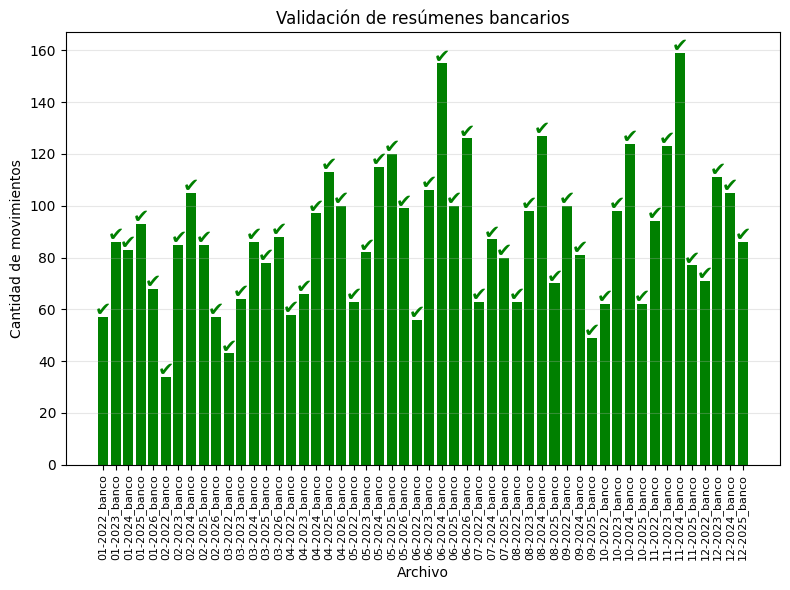

In [ ]:
# Generamos un dataset solo para hacer un plot con cantidad de movimientos
resumen = []
for archivo in os.listdir(carpeta):
    print(archivo)
    if archivo.lower().endswith(".pdf"):
        ruta_pdf = os.path.join(carpeta, archivo)
        df, estado = extraer_movimientos_bancarios(ruta_pdf)
        df["archivo_origen"] = os.path.splitext(archivo)[0]
        archivos.append(df)
        resumen.append({"Archivo": os.path.splitext(archivo)[0], "Movimientos": len(df),"Estado": estado})

df_final = pd.concat(archivos, ignore_index=True)
df_resumen = pd.DataFrame(resumen)
# Colores
colores = ["green" if estado else "red" for estado in df_resumen["Estado"]
]
plt.figure(figsize=(8,6))
barras = plt.bar(df_resumen["Archivo"], df_resumen["Movimientos"], color=colores)

# Escribir "OK" arriba de cada barra
for barra, estado in zip(barras, df_resumen["Estado"]):
    plt.text( barra.get_x() + barra.get_width()/2, barra.get_height() + 0.3, "✔" if estado else "✖", ha="center",
        fontsize=14, color="green" if estado else "red", fontweight="bold")

plt.title("Validación de resúmenes bancarios")
plt.xlabel("Archivo")
plt.ylabel("Cantidad de movimientos")
plt.xticks(rotation=90, fontsize=8)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# llo guardamos para visualizarlo y/o usarlo en otro lado
df_final.to_csv("D:/Josefina/Proyectos/Datascience/Data_Analytics/Contabilidad_Empresa/data/processed/movimientos_bancarios.csv")